In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt;
import seaborn as sns
%matplotlib inline

In [3]:
df=pd.read_csv('economic_index.csv')
df.head()

,Unnamed: 0,year,month,interest_rate,unemployment_rate,index_price
0,0,2017,12,2.75,5.3,1464
1,1,2017,11,2.50,5.3,1394
2,2,2017,10,2.50,5.3,1357
3,3,2017,9,2.50,5.3,1293
4,4,2017,8,2.50,5.4,1256


In [5]:
df.drop(columns=["Unnamed: 0","year","month"],inplace=True)


In [6]:
df.head()

,interest_rate,unemployment_rate,index_price
0,2.75,5.3,1464
1,2.50,5.3,1394
2,2.50,5.3,1357
3,2.50,5.3,1293
4,2.50,5.4,1256


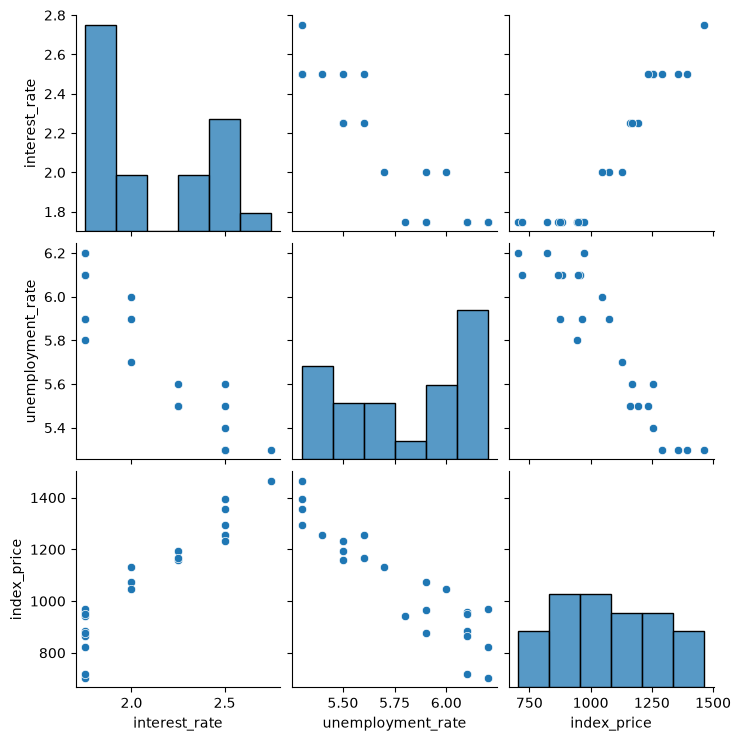

In [8]:
sns.pairplot(df)

In [9]:
df.corr()

,interest_rate,unemployment_rate,index_price
interest_rate,1.000000,-0.925814,0.935793
unemployment_rate,-0.925814,1.000000,-0.922338
index_price,0.935793,-0.922338,1.000000


Text(0, 0.5, 'unemployment_rate')

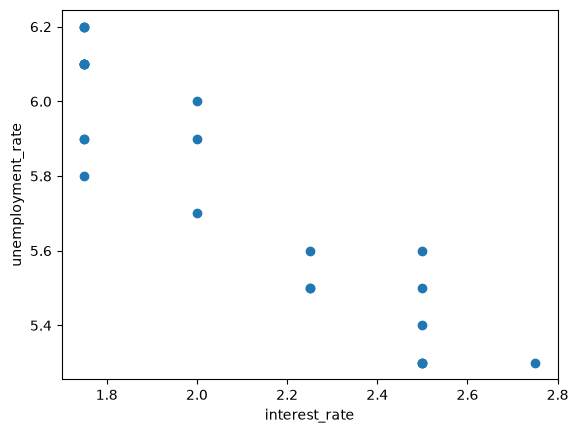

In [11]:
plt.scatter(df['interest_rate'],df['unemployment_rate'])
plt.xlabel("interest_rate")
plt.ylabel("unemployment_rate")

Text(0, 0.5, 'index_price')

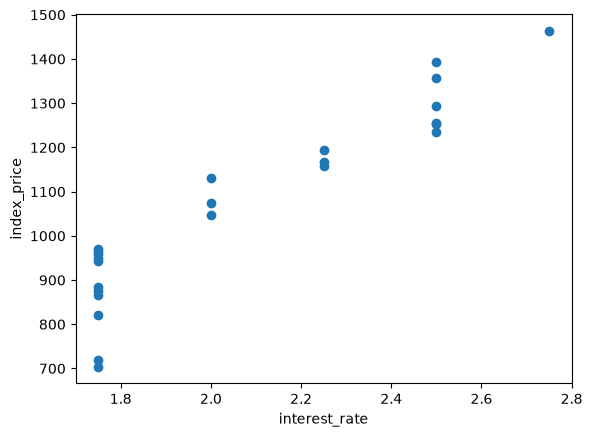

In [12]:
plt.scatter(df['interest_rate'],df['index_price'])
plt.xlabel("interest_rate")
plt.ylabel("index_price")

Text(0, 0.5, 'index_price')

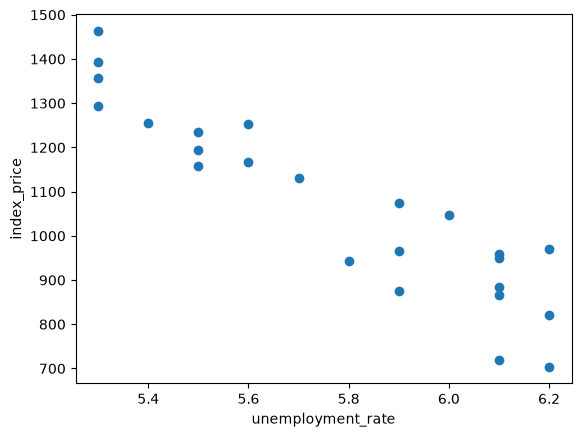

In [13]:
plt.scatter(df['unemployment_rate'],df['index_price'])
plt.xlabel("unemployment_rate")
plt.ylabel("index_price")

In [14]:
#Seperate dependent and independent features
X=df[['interest_rate','unemployment_rate']]
Y=df[['index_price']]

In [16]:
X.head()

,interest_rate,unemployment_rate
0,2.75,5.3
1,2.50,5.3
2,2.50,5.3
3,2.50,5.3
4,2.50,5.4


In [17]:
Y.head()

,index_price
0,1464
1,1394
2,1357
3,1293
4,1256


In [19]:
#split into train and test data
from sklearn.model_selection import train_test_split
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.25,random_state=42)


<Axes: xlabel='interest_rate', ylabel='index_price'>

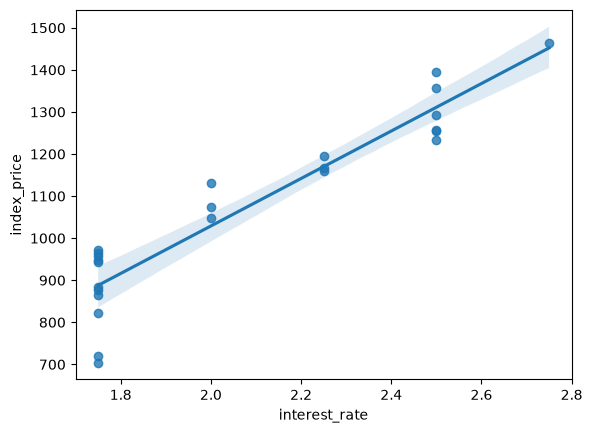

In [22]:
sns.regplot(x=df['interest_rate'], y=df['index_price'])

In [23]:
#scalar transformation
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.fit_transform(X_test)


In [24]:
#Train model
from sklearn.linear_model import LinearRegression
regression=LinearRegression()
regression.fit(X_train,Y_train)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1, 2)","[[ 88.27,-116.26]]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.","ndarray[float64](1,)",[1053.44]
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,2
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(2)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](2,)","[5.87,1.23]"


In [ ]:
#cross validation
from sklearn.model_selection import cross_val_predict
validation_score=cross_val_predict(regression,X_train,Y_train,cv=3)

In [29]:
from sklearn.metrics import mean_squared_error

mse = mean_squared_error(Y_train, validation_score)


In [30]:
mse

5914.828180162386

In [31]:
np.mean(mse)

np.float64(5914.828180162386)

In [32]:
#predication
Y_predict=regression.predict(X_test)


In [33]:
#performance metrics
from sklearn.metrics import mean_absolute_error,mean_squared_error
mse=mean_squared_error(Y_test,Y_predict)
mae=mean_absolute_error(Y_test,Y_predict)
rmse=np.sqrt(mse)
print(mse)
print(mae)
print(rmse)



8108.567426306604
73.80444932337097
90.04758423359621


In [34]:
from sklearn.metrics import r2_score
score=r2_score(Y_test,Y_predict)
print(score)
#adjusted r2 score
1-(1-score)*(len(Y_test)-1)/(len(Y_test)-X_test.shape[1]-1)
Y_train_predict = regression.predict(X_train)

print("Train R2:", r2_score(Y_train, Y_train_predict))
print("Test R2:", r2_score(Y_test, Y_predict))


0.7591371539010257
Train R2: 0.9030782287244159
Test R2: 0.7591371539010257


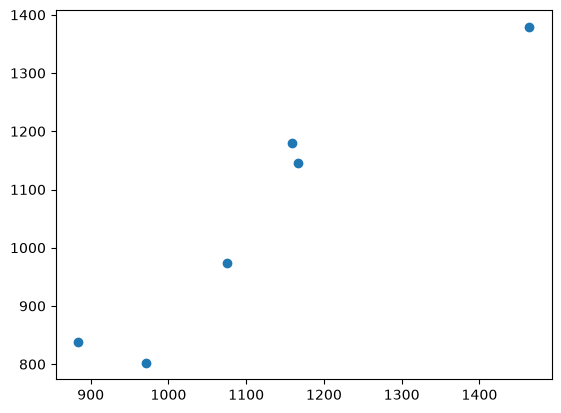

In [35]:
#Assumptions
plt.scatter(Y_test,Y_predict)

In [36]:
error=Y_test-Y_predict
print(error)

    index_price
8    -21.746681
16   168.257203
0     84.165430
18    45.474004
11   101.146860
9     22.036518


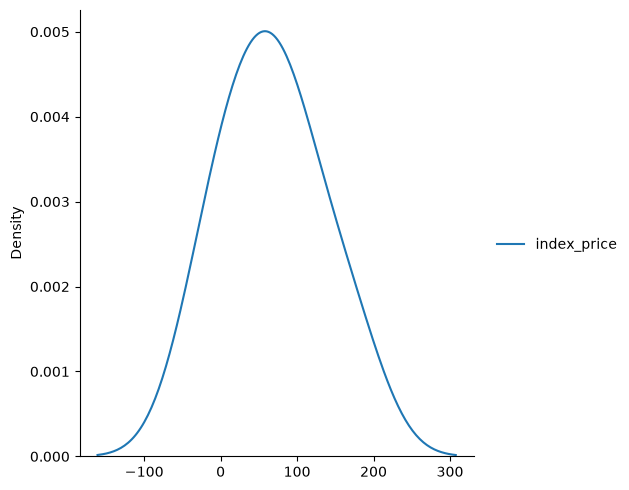

In [37]:
sns.displot(error,kind='kde')

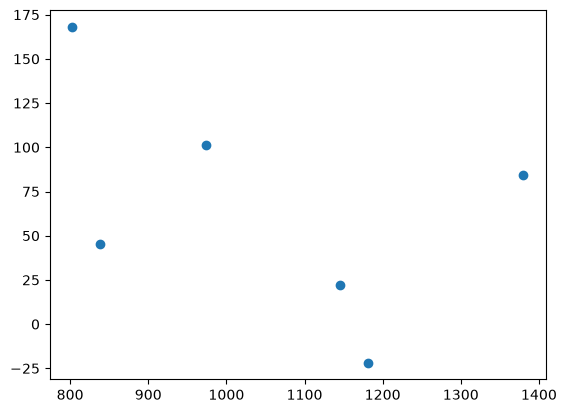

In [38]:
plt.scatter(Y_predict, error)